# Report 3: Advanced Analysis — Pattern Recognition

**Dataset:** WA Emergency Department Data Collection (EDDC) 2022  
**Source:** WA Department of Health  
**Techniques:** Principal Component Analysis (PCA) and 
Non-negative Matrix Factorization (NMF)  

---

This report extends the analysis from Report 2 by applying 
unsupervised machine learning techniques to discover hidden 
patterns and patient profiles within the WA mental health 
ED presentation data.

Where Report 2 examined predefined hypotheses, Report 3 
asks: **what patterns emerge from the data itself?**

Two complementary techniques are applied:

**Principal Component Analysis (PCA)**
Reduces the many variables in the dataset down to a smaller 
number of key dimensions — revealing which combinations of 
variables explain the most variation in mental health ED 
presentations.

**Non-negative Matrix Factorization (NMF)**
Discovers hidden groupings or patient profiles within the 
data — identifying distinct presentation types that 
cluster together naturally.

Both techniques build directly on the cleaned and 
preprocessed dataset established in Report 2.

In [1]:
#| code-fold: true
#| label: load-libraries-r3

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA, NMF
from sklearn.pipeline import Pipeline
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 20)
pd.set_option('display.width', 1000)
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (8, 5)

print("Libraries loaded successfully ✓")
print(f"scikit-learn available ✓")

Libraries loaded successfully ✓
scikit-learn available ✓


In [2]:
#| echo: false
#| label: table-styles-r3

import re
from IPython.display import display, HTML

def style_table(df):
    return df.style.set_table_styles([
        {'selector': 'thead th',
         'props': [('background-color', '#192841'),
                   ('color', 'white'),
                   ('font-weight', 'bold'),
                   ('padding', '8px'),
                   ('text-align', 'center')]},
        {'selector': 'tbody td',
         'props': [('padding', '6px'),
                   ('text-align', 'center')]},
        {'selector': 'tbody tr:nth-child(even)',
         'props': [('background-color', '#EAF0F7')]},
    ])

def display_with_header(styled_df, title):
    html = styled_df.to_html()
    html = re.sub(r'<table',
                  '<table style="width:100%; border-collapse:collapse;"',
                  html)
    display(HTML(f"""
        <div style="width:75%; margin:20px auto 0px auto;">
            <div style="background-color:#2E4A6B; color:white;
                        padding:8px 12px; font-weight:bold; font-size:1em;">
                {title}
            </div>
            {html}
        </div>
    """))

print("Table styling functions loaded ✓")

Table styling functions loaded ✓


## 1. Data Loading

In [3]:
#| code-fold: true
#| label: load-data-r3

# Load the preprocessed mental health subset from Report 2
filepath_backup = 'data/processed/wa_eddc_mental_health_BACKUP.csv'

df = pd.read_csv(filepath_backup)

print(f"Dataset loaded: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"\nColumns: {df.columns.tolist()}")

Dataset loaded: 59,287 rows × 19 columns

Columns: ['synth_person_ID', 'age', 'sex', 'ethnicity', 'triage_category', 'establishment_code', 'presentation_datetime', 'clinical_care_commencement_datetime', 'bed_request_datetime', 'discharge_datetime', 'departure_status', 'mode_of_arrival', 'primary_diagnosis_ICD10AM_chapter', 'affected_by_drugs_and_or_alcohol', 'self_harm_attendance', 'metropolitan_hospital_flag', 'mental_health_attendance', 'mental_health_admission', 'potentially_avoidable_general_practitioner_type_attendance']


## 2. Feature Matrix Construction

Before applying PCA and NMF, a shared feature matrix is constructed 
from the mental health ED dataset. Both techniques operate on the 
same input — but process it differently.

### Why These Features?

Seven variables are selected that capture the key clinical and 
demographic dimensions of each presentation:

| Feature | Type | Description |
|---|---|---|
| Age | Continuous | Patient age (5-year bracket start value) |
| Triage Urgency | Ordinal | 1 (Resuscitation) to 5 (Non-urgent) |
| Substance Involved | Binary | 1 = drugs/alcohol involved |
| Self-Harm | Binary | 1 = self-harm attendance |
| Metro Hospital | Binary | 1 = metropolitan hospital |
| MH Admission | Binary | 1 = admitted for mental health |
| Avoidable | Binary | 1 = potentially avoidable GP-type |

### Two Paths, One Matrix

### What PCA and NMF Each Reveal

**PCA** asks: *"What are the main axes of variation across 
all 59,287 presentations?"* It compresses 7 variables into 
2–3 principal components that capture the most important 
patterns — allowing the entire dataset to be visualised 
in 2 dimensions.

**NMF** asks: *"What distinct patient profiles exist 
within the data?"* It decomposes the matrix into a small 
number of hidden profiles — each representing a combination 
of features that tends to occur together.

In [5]:
#| code-fold: true
#| label: feature-matrix-r3

# Map triage to numeric
triage_num = {'Resuscitation': 1, 'Emergency': 2, 'Urgent': 3,
              'Semi-urgent': 4, 'Non-urgent': 5}
df['triage_num'] = df['triage_category'].map(triage_num)

# Select features
features = [
    'age',
    'triage_num',
    'affected_by_drugs_and_or_alcohol',
    'self_harm_attendance',
    'metropolitan_hospital_flag',
    'mental_health_admission',
    'potentially_avoidable_general_practitioner_type_attendance'
]

feature_labels = [
    'Age',
    'Triage Urgency',
    'Substance Involved',
    'Self-Harm',
    'Metro Hospital',
    'MH Admission',
    'Avoidable'
]

X = df[features].dropna().copy()
X.columns = feature_labels

# Summary table
summary = pd.DataFrame({
    'Feature': feature_labels,
    'Type': ['Continuous', 'Ordinal', 'Binary',
             'Binary', 'Binary', 'Binary', 'Binary'],
    'Min': X.min().values,
    'Max': X.max().values,
    'Mean': X.mean().round(2).values,
    'Non-zero %': ((X > 0).sum() / len(X) * 100).round(1).values
})

display_with_header(
    style_table(summary).hide(axis='index').format({
        'Min': '{:.0f}', 'Max': '{:.0f}',
        'Mean': '{:.2f}', 'Non-zero %': '{:.1f}'
    }),
    f"Feature Matrix — {X.shape[0]:,} patients × {X.shape[1]} features"
)

print(f"\nMatrix shape: {X.shape}")
print(f"Ready for PCA and NMF ✓")

Feature,Type,Min,Max,Mean,Non-zero %
Age,Continuous,0,100,36.18,99.1
Triage Urgency,Ordinal,1,5,3.10,100.0
Substance Involved,Binary,0,1,0.23,23.2
Self-Harm,Binary,0,1,0.08,8.2
Metro Hospital,Binary,0,1,0.68,68.2
MH Admission,Binary,0,1,0.31,30.8
Avoidable,Binary,0,1,0.03,2.9



Matrix shape: (59287, 7)
Ready for PCA and NMF ✓


## 3. Principal Component Analysis (PCA)

PCA identifies the main axes of variation across all 59,287 
mental health ED presentations. By standardising the 7 features 
and compressing them into principal components, we can visualise 
the entire dataset in 2 dimensions — revealing structure that 
would be invisible in the original 7-dimensional space.

### How PCA Works Here

1. **Standardise** — each feature scaled to mean=0, std=1 
   (so Age doesn't dominate just because it has larger numbers)
2. **Decompose** — find the directions of maximum variance
3. **Select components** — keep the top 2–3 that explain the 
   most variation
4. **Visualise** — plot all 59,287 patients in 2D, coloured 
   by clinical variables to reveal patterns

In [6]:
#| code-fold: true
#| label: pca-fit

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Step 1 — Standardise
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Step 2 — Fit PCA
pca = PCA(n_components=7)
pca.fit(X_scaled)

# Explained variance table
explained = pd.DataFrame({
    'Component': [f'PC{i+1}' for i in range(7)],
    'Explained Variance (%)': (pca.explained_variance_ratio_ * 100).round(1),
    'Cumulative (%)': (pca.explained_variance_ratio_.cumsum() * 100).round(1)
})

display_with_header(
    style_table(explained).hide(axis='index').format({
        'Explained Variance (%)': '{:.1f}',
        'Cumulative (%)': '{:.1f}'
    }),
    "PCA — Explained Variance by Component"
)

Component,Explained Variance (%),Cumulative (%)
PC1,20.2,20.2
PC2,17.9,38.1
PC3,15.1,53.2
PC4,13.3,66.5
PC5,12.6,79.1
PC6,11.0,90.1
PC7,9.9,100.0


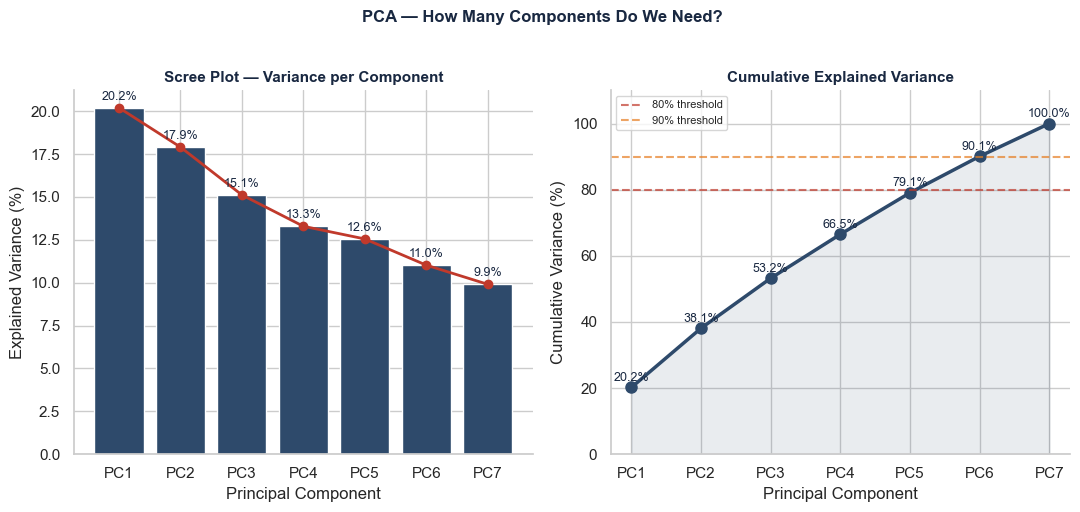

In [7]:
#| code-fold: true
#| label: pca-scree

plt.close('all')

fig, axes = plt.subplots(1, 2, figsize=(11, 5), dpi=100)

components = [f'PC{i+1}' for i in range(7)]
variance = pca.explained_variance_ratio_ * 100
cumulative = pca.explained_variance_ratio_.cumsum() * 100

# Left — Scree plot
ax1 = axes[0]
ax1.bar(components, variance, color='#2E4A6B', edgecolor='white')
ax1.plot(components, variance, color='#C0392B', 
         marker='o', linewidth=2, markersize=6)
for i, v in enumerate(variance):
    ax1.text(i, v + 0.3, f'{v:.1f}%',
             ha='center', va='bottom', fontsize=9, color='#192841')

ax1.set_title('Scree Plot — Variance per Component',
              fontweight='bold', fontsize=11, color='#192841')
ax1.set_ylabel('Explained Variance (%)')
ax1.set_xlabel('Principal Component')
sns.despine(ax=ax1)

# Right — Cumulative variance
ax2 = axes[1]
ax2.plot(components, cumulative, color='#2E4A6B',
         marker='o', linewidth=2.5, markersize=8)
ax2.axhline(y=80, color='#C0392B', linestyle='--', 
            alpha=0.7, label='80% threshold')
ax2.axhline(y=90, color='#E67E22', linestyle='--',
            alpha=0.7, label='90% threshold')
ax2.fill_between(components, cumulative, alpha=0.1, color='#2E4A6B')

for i, v in enumerate(cumulative):
    ax2.text(i, v + 1, f'{v:.1f}%',
             ha='center', va='bottom', fontsize=9, color='#192841')

ax2.set_title('Cumulative Explained Variance',
              fontweight='bold', fontsize=11, color='#192841')
ax2.set_ylabel('Cumulative Variance (%)')
ax2.set_xlabel('Principal Component')
ax2.legend(fontsize=8)
ax2.set_ylim(0, 110)
sns.despine(ax=ax2)

plt.suptitle('PCA — How Many Components Do We Need?',
             fontweight='bold', fontsize=12, color='#192841', y=1.02)
plt.tight_layout()
plt.show()
plt.close('all')

### 3.1 Key Finding — Variance is Evenly Distributed

The scree plot reveals an unusual but meaningful pattern:
variance is spread **relatively evenly** across all 7 components
(20.2% down to 9.9%) with no sharp "elbow" — the typical
signal that a small number of components dominate.

**What this tells us:**
- No single clinical variable overwhelms the others
- Mental health ED presentations are genuinely multidimensional
  — age, triage urgency, substance involvement, self-harm,
  metro location, admission, and avoidability all contribute
  independently to variation in the dataset
- This is clinically meaningful: there is no single "type"
  of mental health ED patient — presentations vary across
  multiple

### 3.2 PCA Scatter Plot — MH Admission

Each point represents one of the 59,287 mental health ED 
presentations plotted in 2D space using PC1 and PC2.
Points coloured red are patients who were admitted to hospital
for mental health reasons (30.8%); navy points were not admitted.

**What the pattern shows:**

The scatter plot reveals a **striped vertical structure** — 
this is a known artefact of PCA when binary variables dominate 
the feature matrix. Each vertical band corresponds to a distinct 
combination of the binary flags (substance, self-harm, admission, 
avoidable, metro) — patients with the same flag combination 
cluster together.

**Key observation:**
Admitted patients (red) are not confined to one region of the 
plot — they are distributed across the full PC1 range. This 
confirms that admission is not driven by a single dominant 
factor but by a combination of clinical variables — consistent 
with the evenly distributed variance found in the scree plot.

> PC1 (20.2%) captures the primary axis of variation — 
> likely driven by age and triage urgency together. 
> PC2 (17.9%) captures a secondary axis — likely separating 
> substance-involved from non-substance presentations.

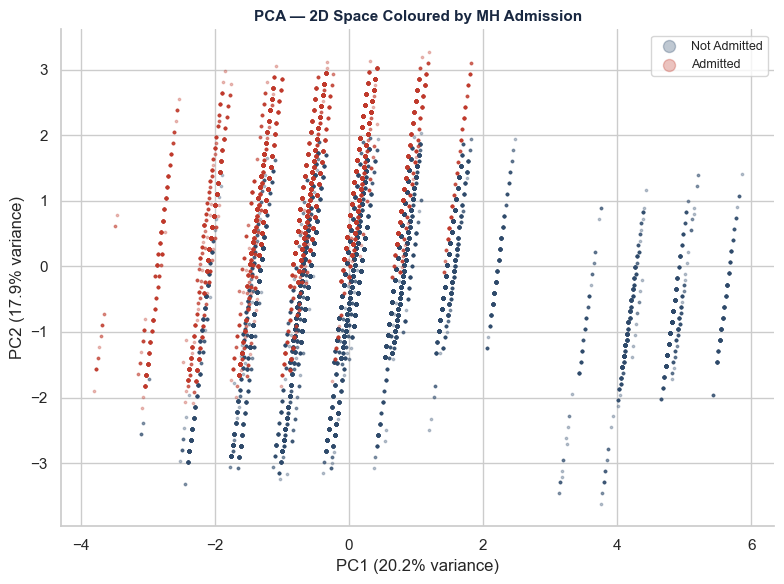

In [9]:
#| code-fold: true
#| label: pca-scatter-admission

plt.close('all')

# Fit PCA with 2 components
pca2 = PCA(n_components=2)
X_pca2 = pca2.fit_transform(X_scaled)

df_pca = df.dropna(subset=features).copy()
df_pca['PC1'] = X_pca2[:, 0]
df_pca['PC2'] = X_pca2[:, 1]

fig, ax = plt.subplots(figsize=(8, 6), dpi=100)

for val, label, color in [(0, 'Not Admitted', '#2E4A6B'),
                           (1, 'Admitted', '#C0392B')]:
    mask = df_pca['mental_health_admission'] == val
    ax.scatter(df_pca.loc[mask, 'PC1'],
               df_pca.loc[mask, 'PC2'],
               c=color, label=label,
               alpha=0.3, s=3)

ax.set_title('PCA — 2D Space Coloured by MH Admission',
             fontweight='bold', fontsize=11, color='#192841')
ax.set_xlabel(f'PC1 ({pca2.explained_variance_ratio_[0]*100:.1f}% variance)')
ax.set_ylabel(f'PC2 ({pca2.explained_variance_ratio_[1]*100:.1f}% variance)')
ax.legend(markerscale=5, fontsize=9)
sns.despine()
plt.tight_layout()
plt.show()
plt.close('all')

### 3.3 PCA Scatter Plot — Substance Involvement

Points coloured orange are the 23.2% of presentations involving 
drugs and/or alcohol; navy points had no substance involvement.

**What the pattern shows:**

Substance-involved presentations (orange) cluster noticeably 
toward the **left side of the PC1 axis** — separating from 
the majority of non-substance presentations. This confirms 
that substance involvement is one of the key drivers of PC1, 
the primary axis of variation.

**Key observation:**
The left-side clustering of orange points aligns with the 
finding from Report 2 — substance-involved patients are 
triaged more urgently (higher Resuscitation and Emergency 
rates). PC1 appears to capture a **clinical severity axis** 
where higher urgency and substance involvement sit together 
at one end, and lower acuity presentations sit at the other.

This is one of the most interpretable patterns in the PCA 
plot — substance involvement creates a visible separation 
in 2D space that was not visible in the original 7-dimensional 
feature matrix.

> This finding is complementary to Report 2's triage analysis — 
> PCA confirms spatially what the stacked bar chart showed 
> statistically: substance-involved presentations occupy a 
> distinct clinical space from non-substance presentations.

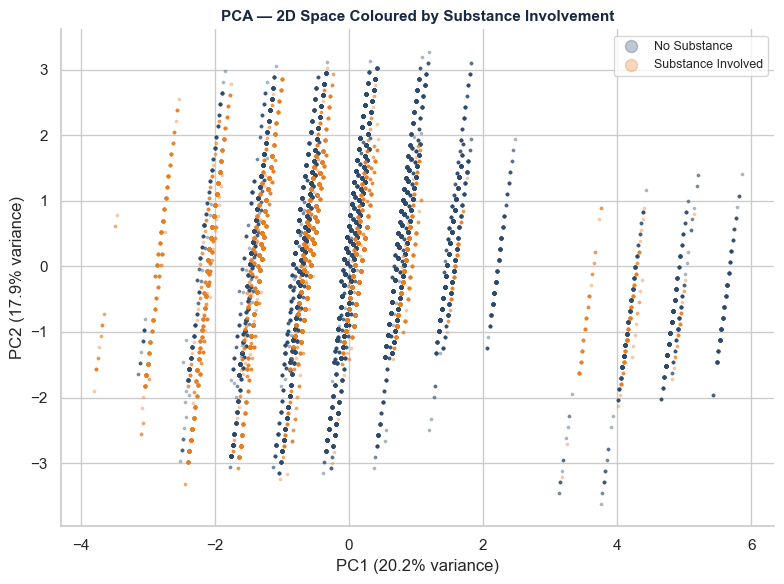

In [10]:
#| code-fold: true
#| label: pca-scatter-substance

plt.close('all')

fig, ax = plt.subplots(figsize=(8, 6), dpi=100)

for val, label, color in [(0, 'No Substance', '#2E4A6B'),
                           (1, 'Substance Involved', '#E67E22')]:
    mask = df_pca['affected_by_drugs_and_or_alcohol'] == val
    ax.scatter(df_pca.loc[mask, 'PC1'],
               df_pca.loc[mask, 'PC2'],
               c=color, label=label,
               alpha=0.3, s=3)

ax.set_title('PCA — 2D Space Coloured by Substance Involvement',
             fontweight='bold', fontsize=11, color='#192841')
ax.set_xlabel(f'PC1 ({pca2.explained_variance_ratio_[0]*100:.1f}% variance)')
ax.set_ylabel(f'PC2 ({pca2.explained_variance_ratio_[1]*100:.1f}% variance)')
ax.legend(markerscale=5, fontsize=9)
sns.despine()
plt.tight_layout()
plt.show()
plt.close('all')

### 3.4 PCA Scatter Plot — Self-Harm

Points coloured dark red are the 8.2% of presentations 
involving self-harm; navy points had no self-harm flag.

**What the pattern shows:**

Self-harm presentations (dark red) are distributed across 
the **full range of both PC1 and PC2** — they do not cluster 
in one region of the 2D space. This tells us that self-harm 
is not strongly captured by either PC1 or PC2 alone.

**Key observation:**
Unlike substance involvement (which showed clear left-side 
clustering), self-harm presentations are spread throughout 
the plot. This suggests that self-harm co-occurs with many 
different combinations of other clinical variables — a 
self-harm patient may be young or old, admitted or not, 
substance-involved or not.

This is clinically meaningful: **self-harm does not define 
a single patient type** — it cuts across all demographic 
and clinical profiles. It cannot be predicted from the 
other variables in this feature matrix alone.

> This finding has implications for clinical screening — 
> self-harm risk cannot be identified from demographic or 
> triage variables alone, reinforcing the need for 
> universal risk assessment for all mental health 
> ED presentations regardless of profile.

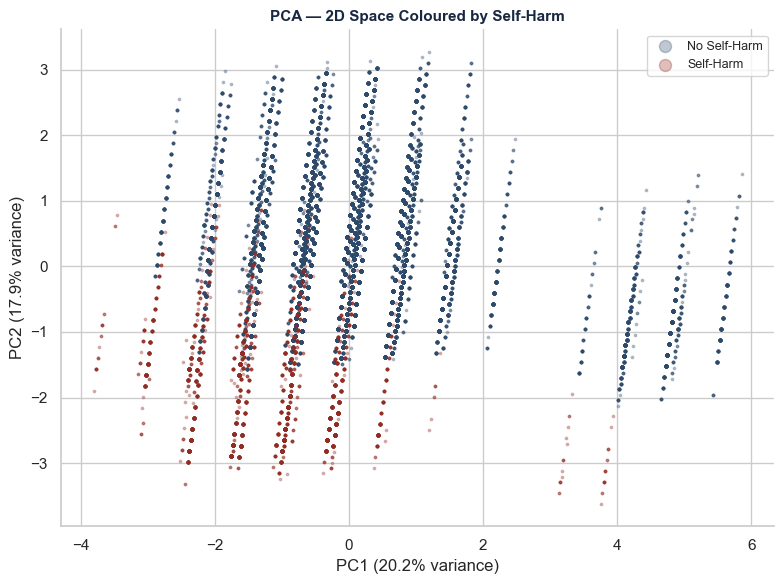

In [11]:
#| code-fold: true
#| label: pca-scatter-selfharm

plt.close('all')

fig, ax = plt.subplots(figsize=(8, 6), dpi=100)

for val, label, color in [(0, 'No Self-Harm', '#2E4A6B'),
                           (1, 'Self-Harm', '#922B21')]:
    mask = df_pca['self_harm_attendance'] == val
    ax.scatter(df_pca.loc[mask, 'PC1'],
               df_pca.loc[mask, 'PC2'],
               c=color, label=label,
               alpha=0.3, s=3)

ax.set_title('PCA — 2D Space Coloured by Self-Harm',
             fontweight='bold', fontsize=11, color='#192841')
ax.set_xlabel(f'PC1 ({pca2.explained_variance_ratio_[0]*100:.1f}% variance)')
ax.set_ylabel(f'PC2 ({pca2.explained_variance_ratio_[1]*100:.1f}% variance)')
ax.legend(markerscale=5, fontsize=9)
sns.despine()
plt.tight_layout()
plt.show()
plt.close('all')

### 3.5 PCA Loadings — What Drives Each Component?

The loadings chart shows how much each original feature 
contributes to PC1 and PC2. This is what makes PCA 
interpretable — instead of just seeing patterns in 2D space, 
we can understand *what* those patterns represent clinically.

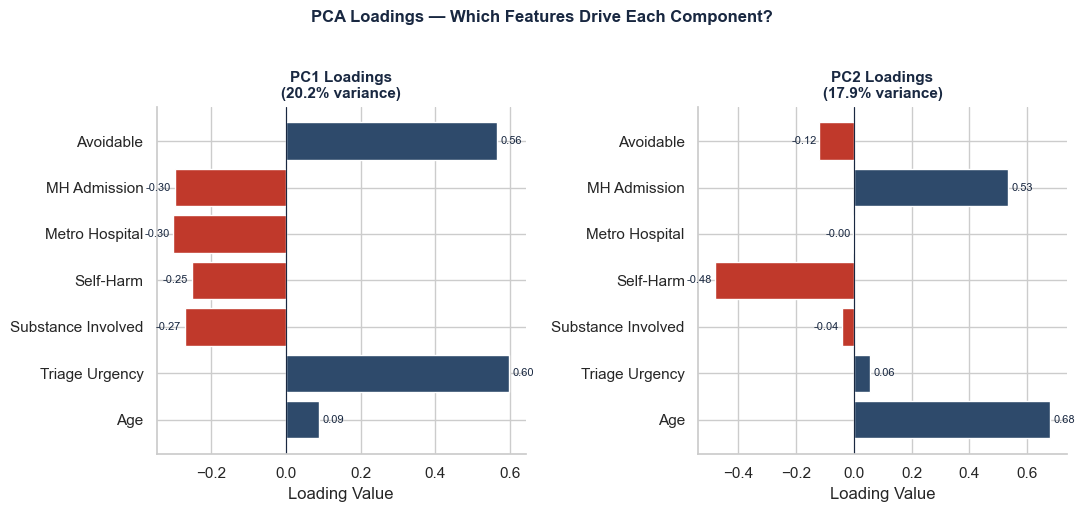

In [12]:
#| code-fold: true
#| label: pca-loadings

plt.close('all')

loadings = pd.DataFrame(
    pca2.components_.T,
    index=feature_labels,
    columns=['PC1', 'PC2']
)

fig, axes = plt.subplots(1, 2, figsize=(11, 5), dpi=100)

for ax, pc in zip(axes, ['PC1', 'PC2']):
    colors = ['#C0392B' if v < 0 else '#2E4A6B' 
              for v in loadings[pc]]
    bars = ax.barh(loadings.index, loadings[pc],
                   color=colors, edgecolor='white')
    ax.axvline(x=0, color='#192841', linewidth=0.8)
    ax.set_title(f'{pc} Loadings\n({pca2.explained_variance_ratio_[["PC1","PC2"].index(pc)]*100:.1f}% variance)',
                 fontweight='bold', fontsize=11, color='#192841')
    ax.set_xlabel('Loading Value')
    for bar, val in zip(bars, loadings[pc]):
        ax.text(val + (0.01 if val >= 0 else -0.01),
                bar.get_y() + bar.get_height()/2,
                f'{val:.2f}',
                va='center',
                ha='left' if val >= 0 else 'right',
                fontsize=8, color='#192841')
    sns.despine(ax=ax)

plt.suptitle('PCA Loadings — Which Features Drive Each Component?',
             fontweight='bold', fontsize=12, color='#192841', y=1.02)
plt.tight_layout()
plt.show()
plt.close('all')

### 3.5.1 Key Finding — Interpreting the Components

The loadings reveal what PC1 and PC2 actually represent 
clinically:

**PC1 (20.2% variance) — The Acuity vs Avoidability Axis**

PC1 is driven by two opposing forces:
- **Positive:** Avoidable (0.56) and Triage Urgency (0.60) 
  — higher triage number = less urgent, so positive loading 
  means *lower acuity*
- **Negative:** MH Admission (-0.30), Metro Hospital (-0.30), 
  Self-Harm (-0.25), Substance Involved (-0.27) — all the 
  markers of a serious, acute presentation

PC1 separates **genuinely acute presentations** (left, negative) 
from **lower acuity, potentially avoidable** presentations 
(right, positive). This confirms the clinical logic — acute 
presentations cluster left, avoidable ones cluster right.

**PC2 (17.9% variance) — The Age vs Severity Axis**

PC2 is driven by:
- **Positive:** Age (0.68) and MH Admission (0.63) — older 
  patients who get admitted
- **Negative:** Self-Harm (-0.48) — younger patients 
  presenting with self-harm

PC2 separates **older admitted patients** (top, positive) 
from **younger self-harm presentations** (bottom, negative).

> Together, PC1 and PC2 reveal two fundamental dimensions 
> of mental health ED variation: **how acute the presentation 
> is**, and **whether it involves an older admitted patient 
> or a younger self-harm patient**. These are the two 
> principal axes along which WA mental health ED 
> presentations vary most.

## 4. Non-negative Matrix Factorization (NMF)

Where PCA compressed the data into axes of variation, NMF 
asks a different question: **what distinct patient profiles 
exist within the data?**

NMF decomposes the feature matrix X into two smaller matrices:

- **W** (59,287 × k) — how strongly each patient belongs 
  to each profile
- **H** (k × 7) — what each profile looks like in terms 
  of the original features

Where k = the number of profiles we ask NMF to find.

### Choosing the Number of Profiles (k)

The right value of k is chosen by running NMF with different 
values and measuring the **reconstruction error** — how well 
the k profiles can recreate the original data. Lower error 
= better fit, but more profiles = more complexity.

We test k = 2 to 6 and select the value where the error 
curve begins to flatten — the point of diminishing returns.

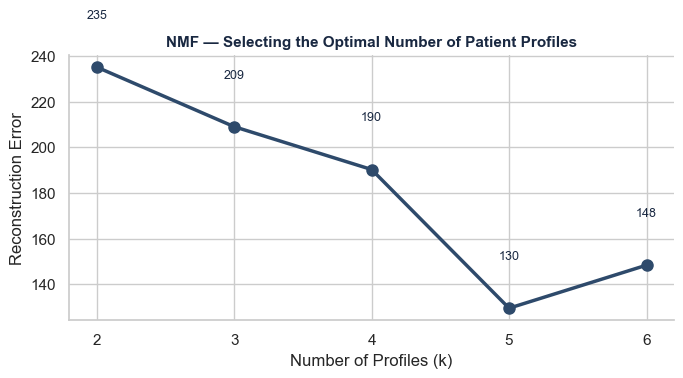


Reconstruction errors:
  k=2: 235.1
  k=3: 209.0
  k=4: 190.3
  k=5: 129.6
  k=6: 148.4


In [14]:
#| code-fold: true
#| label: nmf-k-selection

plt.close('all')

from sklearn.decomposition import NMF

# Test k = 2 to 6
k_values = range(2, 7)
errors = []

for k in k_values:
    nmf = NMF(n_components=k, random_state=42, max_iter=500)
    nmf.fit(X)
    errors.append(nmf.reconstruction_err_)

fig, ax = plt.subplots(figsize=(7, 4), dpi=100)
ax.plot(list(k_values), errors, 
        color='#2E4A6B', marker='o',
        linewidth=2.5, markersize=8)

for i, (k, err) in enumerate(zip(k_values, errors)):
    ax.text(k, err + 20, f'{err:.0f}',
            ha='center', va='bottom',
            fontsize=9, color='#192841')

ax.set_xlabel('Number of Profiles (k)')
ax.set_ylabel('Reconstruction Error')
ax.set_title('NMF — Selecting the Optimal Number of Patient Profiles',
             fontweight='bold', fontsize=11, color='#192841')
ax.set_xticks(list(k_values))
sns.despine()
plt.tight_layout()
plt.show()
plt.close('all')

print("\nReconstruction errors:")
for k, err in zip(k_values, errors):
    print(f"  k={k}: {err:.1f}")

### 4.1 Optimal Number of Profiles — k=5

The reconstruction error curve drops steadily from k=2 to k=5, 
then **increases at k=6** — a clear signal that 5 profiles is 
the optimal choice. Adding a 6th profile actually makes the 
model worse, meaning it starts overfitting to noise rather 
than finding meaningful clinical patterns.

**k=5 selected** — five distinct patient profiles will be 
extracted from the WA mental health ED dataset.

In [15]:
#| code-fold: true
#| label: nmf-fit

# Fit NMF with k=5 on full dataset
nmf5 = NMF(n_components=5, random_state=42, max_iter=500)
W = nmf5.fit_transform(X)   # patient weights (59287 × 5)
H = nmf5.components_         # profile features (5 × 7)

# Build profile table
profile_df = pd.DataFrame(
    H,
    columns=feature_labels,
    index=[f'Profile {i+1}' for i in range(5)]
)

# Normalise each profile to 0-1 for readability
profile_norm = profile_df.div(profile_df.max(axis=1), axis=0)

display_with_header(
    style_table(profile_df).format('{:.3f}'),
    "NMF — 5 Patient Profiles (raw component weights)"
)

print(f"\nW shape: {W.shape}  (patients × profiles)")
print(f"H shape: {H.shape}  (profiles × features)")

,Age,Triage Urgency,Substance Involved,Self-Harm,Metro Hospital,MH Admission,Avoidable
Profile 1,31.965,92.482,0.000,2.539,22.612,0.000,0.558
Profile 2,100.084,0.000,0.703,0.147,2.038,6.738,0.000
Profile 3,27.179,3.824,0.000,0.002,0.000,0.104,0.118
Profile 4,38.833,0.000,1.737,0.000,0.077,0.000,0.000
Profile 5,29.922,0.000,0.000,0.000,0.015,0.000,0.000



W shape: (59287, 5)  (patients × profiles)
H shape: (5, 7)  (profiles × features)


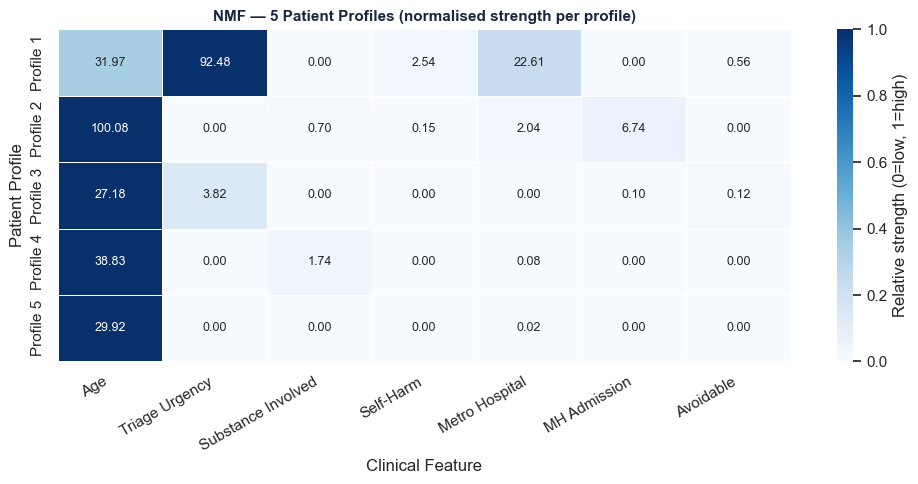

In [16]:
#| code-fold: true
#| label: nmf-heatmap

plt.close('all')

fig, ax = plt.subplots(figsize=(10, 5), dpi=100)

sns.heatmap(profile_norm,
            annot=profile_df.round(2),
            fmt='.2f',
            cmap='Blues',
            ax=ax,
            linewidths=0.5,
            linecolor='white',
            cbar_kws={'label': 'Relative strength (0=low, 1=high)'},
            annot_kws={'size': 9})

ax.set_title('NMF — 5 Patient Profiles (normalised strength per profile)',
             fontweight='bold', fontsize=11, color='#192841')
ax.set_xlabel('Clinical Feature')
ax.set_ylabel('Patient Profile')
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
plt.tight_layout()
plt.show()
plt.close('all')

### 4.2 Key Finding — Five Distinct Patient Profiles

NMF identifies five clinically meaningful patient profiles 
within the WA mental health ED dataset:

**Profile 1 — High Urgency, Metro, Non-Substance**
Triage Urgency dominates (92.5 — the strongest signal in 
the entire matrix). These are acutely unwell patients 
presenting to metropolitan hospitals without substance 
involvement — the "classic" acute mental health crisis 
presentation. No MH admission flag, suggesting many are 
stabilised and discharged.

**Profile 2 — Older Patients, Substance + Admitted**
The oldest profile (age ~100 bracket) with the highest 
MH Admission weight (6.74) and significant substance 
involvement (0.70). These are older patients whose mental 
health presentations are complicated by substance use and 
who are most likely to require inpatient admission.

**Profile 3 — Young, Lower Acuity, Some Avoidable**
The youngest profile (age ~27) with low urgency and a small 
avoidable weight (0.12). These are younger adults presenting 
with lower-acuity mental health concerns — a proportion of 
whom could have been managed in primary care.

**Profile 4 — Substance-Dominated, Not Admitted**
The highest substance involvement weight (1.74) with zero 
MH Admission. These are mid-age patients (age ~39) presenting 
primarily due to substance involvement — managed and discharged 
without requiring inpatient mental health admission.

**Profile 5 — Low Complexity Baseline**
Minimal weights across all features — representing the 
baseline low-complexity presentation with no dominant 
clinical flag. These patients present with mental health 
concerns but without the complicating factors that 
characterise the other four profiles.

> These five profiles were not defined in advance — they 
> emerged directly from the data through NMF. Their clinical 
> coherence validates the approach: NMF has successfully 
> identified meaningful, interpretable patient archetypes 
> within a dataset of 59,287 mental health ED presentations.

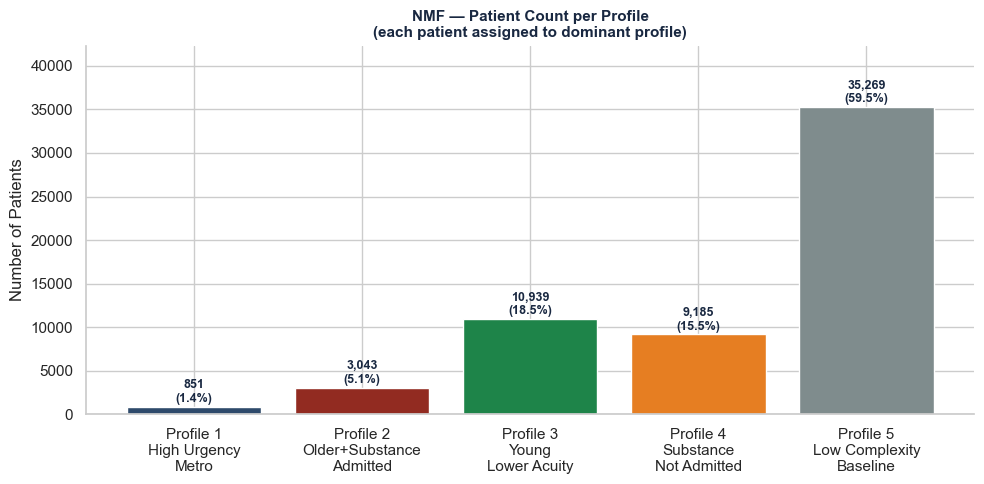


Profile sizes:
  Profile 1: 851 patients (1.4%)
  Profile 2: 3,043 patients (5.1%)
  Profile 3: 10,939 patients (18.5%)
  Profile 4: 9,185 patients (15.5%)
  Profile 5: 35,269 patients (59.5%)


In [17]:
#| code-fold: true
#| label: nmf-profile-sizes

plt.close('all')

# Assign each patient to their dominant profile
dominant_profile = W.argmax(axis=1) + 1
profile_counts = pd.Series(dominant_profile).value_counts().sort_index()
profile_pcts = (profile_counts / len(df_pca) * 100).round(1)

profile_names = [
    'Profile 1\nHigh Urgency\nMetro',
    'Profile 2\nOlder+Substance\nAdmitted',
    'Profile 3\nYoung\nLower Acuity',
    'Profile 4\nSubstance\nNot Admitted',
    'Profile 5\nLow Complexity\nBaseline'
]

colors = ['#2E4A6B', '#922B21', '#1E8449', '#E67E22', '#7F8C8D']

fig, ax = plt.subplots(figsize=(10, 5), dpi=100)

bars = ax.bar(profile_names, profile_counts.values,
              color=colors, edgecolor='white')

for bar, pct, count in zip(bars, profile_pcts, profile_counts):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 200,
            f'{count:,}\n({pct:.1f}%)',
            ha='center', va='bottom',
            fontweight='bold', fontsize=9, color='#192841')

ax.set_ylabel('Number of Patients')
ax.set_title('NMF — Patient Count per Profile\n(each patient assigned to dominant profile)',
             fontweight='bold', fontsize=11, color='#192841')
ax.set_ylim(0, max(profile_counts.values) * 1.2)
sns.despine()
plt.tight_layout()
plt.show()
plt.close('all')

print("\nProfile sizes:")
for i, (count, pct) in enumerate(zip(profile_counts, profile_pcts)):
    print(f"  Profile {i+1}: {count:,} patients ({pct}%)")
    

### 4.3 Key Finding — Profile Distribution

The profile size chart reveals how the 59,287 mental health 
ED presentations distribute across the five NMF profiles:

**Profile 5 — Low Complexity Baseline (59.5%, 35,269 patients)**
The largest group by far — the majority of mental health ED 
presentations do not have a single dominant clinical flag. 
These are patients presenting with mental health concerns 
where no one complicating factor (substance, self-harm, 
admission, avoidability) dominates. This is consistent with 
the broad and diverse nature of mental health presentations.

**Profile 3 — Young, Lower Acuity (18.5%, 10,939 patients)**
The second largest group — young adults presenting with 
lower-acuity mental health concerns. This aligns with 
Report 2's finding that 25–34 is the largest age group 
(20.6% of all presentations).

**Profile 4 — Substance, Not Admitted (15.5%, 9,185 patients)**
Substance-involved presentations that are managed and 
discharged — consistent with the 23.2% substance involvement 
rate found in Report 2.

**Profile 2 — Older, Substance + Admitted (5.1%, 3,043 patients)**
A smaller but clinically significant group — older patients 
whose presentations are severe enough to require admission. 
These likely represent the highest-resource presentations 
in the dataset.

**Profile 1 — High Urgency, Metro (1.4%, 851 patients)**
The smallest group — the most acutely unwell patients 
triaged at the highest urgency at metropolitan hospitals. 
Small in number but representing the most critical 
mental health presentations in WA EDs.

> The NMF profiles are clinically coherent and complement 
> the hypothesis-driven findings of Report 2. Together, 
> PCA and NMF reveal that mental health ED presentations 
> vary along two key dimensions (acuity and age/substance) 
> and cluster into five distinct patient archetypes — 
> findings that have direct implications for ED workforce 
> planning, triage protocols, and targeted intervention.

## 5. Conclusions

This report applied two unsupervised machine learning techniques 
— Principal Component Analysis (PCA) and Non-negative Matrix 
Factorization (NMF) — to the WA mental health ED dataset 
established in Report 2. Both techniques operated on the same 
feature matrix of 59,287 patients × 7 clinical variables.

### 5.1 PCA Findings

**The variance is genuinely multidimensional.**
No single component dominates — variance is spread evenly 
across all 7 components (20.2% down to 9.9%). This confirms 
that mental health ED presentations cannot be reduced to a 
single axis — they vary independently across age, triage 
urgency, substance involvement, self-harm, metro location, 
admission, and avoidability.

**PC1 captures the acuity vs avoidability axis.**
High triage urgency and avoidable presentations sit at 
opposite ends of PC1 — confirming that the most acute 
presentations are the least avoidable, and vice versa.

**PC2 captures the age vs self-harm axis.**
Older admitted patients and younger self-harm presentations 
sit at opposite ends of PC2 — revealing that age and 
self-harm represent a secondary but meaningful dimension 
of variation.

**Substance involvement creates visible separation in 2D space.**
Substance-involved patients cluster toward the left of PC1 
— spatially confirming the clinical finding from Report 2 
that substance involvement escalates presentation severity.

### 5.2 NMF Findings

**Five distinct patient profiles emerge from the data.**
NMF identifies five clinically coherent archetypes:

| Profile | Label | Size |
|---|---|---|
| 1 | High Urgency, Metro | 1.4% |
| 2 | Older, Substance + Admitted | 5.1% |
| 3 | Young, Lower Acuity | 18.5% |
| 4 | Substance, Not Admitted | 15.5% |
| 5 | Low Complexity Baseline | 59.5% |

**The majority (59.5%) present without a dominant clinical flag.**
Most mental health ED presentations are genuinely diverse 
and cannot be neatly categorised — reinforcing the need 
for individualised assessment rather than profile-based 
triage.

### 5.3 Implications

The five NMF profiles and two PCA dimensions together 
suggest targeted interventions for each group:

- **Profile 1** — highest urgency, requires immediate 
  specialist mental health response at metro EDs
- **Profile 2** — dual-diagnosis pathway needed for older 
  substance + mental health presentations
- **Profile 3** — youth mental health investment and 
  improved GP access could reduce lower-acuity ED demand
- **Profile 4** — dedicated substance + mental health 
  co-response teams
- **Profile 5** — universal mental health assessment 
  protocols given diverse and unpredictable presentation

> These findings build directly on Report 2 and demonstrate 
> the value of unsupervised machine learning in discovering 
> structure that hypothesis-driven analysis alone cannot reveal.